In [12]:
# Imports
from data_preprocessing import standardize_dates, add_days_to_floraison, NIRS_INDEXES, NIRS_INDEXES_INT
from utils import varimax
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

In [3]:
# Load and preprocess the data
data = pd.read_csv("./Data/CIRAD_Sorghum2023_SPIR_all_2 (4).csv", sep=";")
data = standardize_dates(data)
data = add_days_to_floraison(data)
data

,Genotype,Sample,ID,Date_Floraison,Date_SPIR,Traitement,Rep,Position,350,351,...,2492,2493,2494,2495,2496,2497,2498,2499,2500,Dates_Delta
0,Btx623,FreshLeaf,117,2023-05-19,2023-06-01,C,1,FlagLeaf,0.075652,0.070583,...,0.085991,0.085268,0.084832,0.084246,0.083982,0.083914,0.083658,0.083273,0.083111,13
1,Btx623,FreshLeaf,117,2023-05-19,2023-06-01,C,2,FlagLeaf,0.083377,0.082926,...,0.101342,0.101169,0.100833,0.100403,0.100057,0.099492,0.099523,0.099310,0.099126,13
2,Macia,FreshLeaf,203,2023-05-23,2023-06-01,SS2,1,FlagLeaf,0.078272,0.075389,...,0.078159,0.078018,0.077781,0.077200,0.077168,0.077273,0.077200,0.077064,0.076751,9
3,Macia,FreshLeaf,203,2023-05-23,2023-06-01,SS2,2,FlagLeaf,0.075764,0.074639,...,0.078284,0.078045,0.077868,0.077812,0.077722,0.077669,0.077620,0.077650,0.077399,9
4,Macia,FreshLeaf,215,2023-05-24,2023-06-01,C,1,FlagLeaf,0.061362,0.060504,...,0.068550,0.068382,0.068200,0.068012,0.067757,0.067621,0.067635,0.067188,0.067004,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2169,Btx623,GrainFlour,97,2023-05-17,2023-11-23,RS1,2,H,0.034959,0.030955,...,0.047863,0.047645,0.047588,0.047305,0.047117,0.047099,0.046816,0.046783,0.047026,190
2170,Btx623,GrainFlour,9,2023-05-17,2023-11-23,RS1,1,B,0.032963,0.032206,...,0.028890,0.028442,0.028247,0.028060,0.028358,0.028750,0.029092,0.029434,0.029362,190
2171,Btx623,GrainFlour,9,2023-05-17,2023-11-23,RS1,2,B,0.027549,0.022803,...,0.038462,0.038161,0.038029,0.037948,0.038023,0.038103,0.038269,0.038595,0.038484,190
2172,Btx623,GrainFlour,9,2023-05-17,2023-11-23,RS1,1,H,0.032928,0.029184,...,0.058592,0.058842,0.058885,0.059198,0.058971,0.058752,0.058847,0.058893,0.059020,190


Explained variance ratio [0.78385687 0.11943057]
Total explained variance ratio 0.9032874425184382


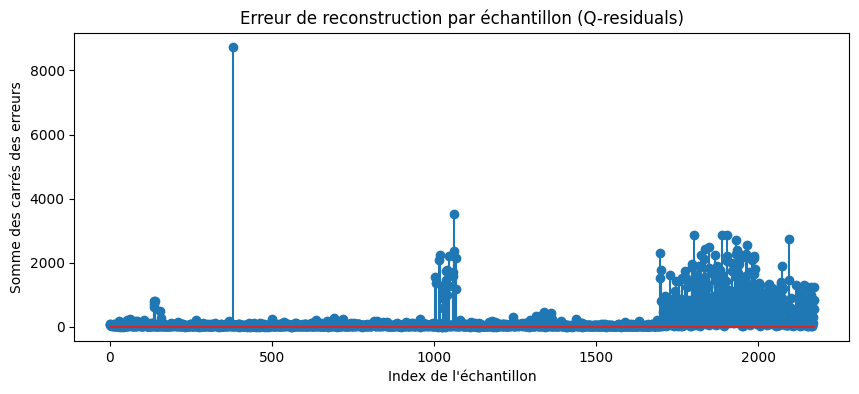

In [26]:
# ACP
X = data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio", pca.explained_variance_ratio_)
print("Total explained variance ratio", np.sum(pca.explained_variance_ratio_))

X_reconstructed = pca.inverse_transform(X_pca)
residus = X_scaled - X_reconstructed

q_residuals = np.sum(residus**2, axis=1)
plt.figure(figsize=(10, 4))
plt.stem(q_residuals)
plt.title("Erreur de reconstruction par échantillon (Q-residuals)")
plt.xlabel("Index de l'échantillon")
plt.ylabel("Somme des carrés des erreurs")
plt.show()

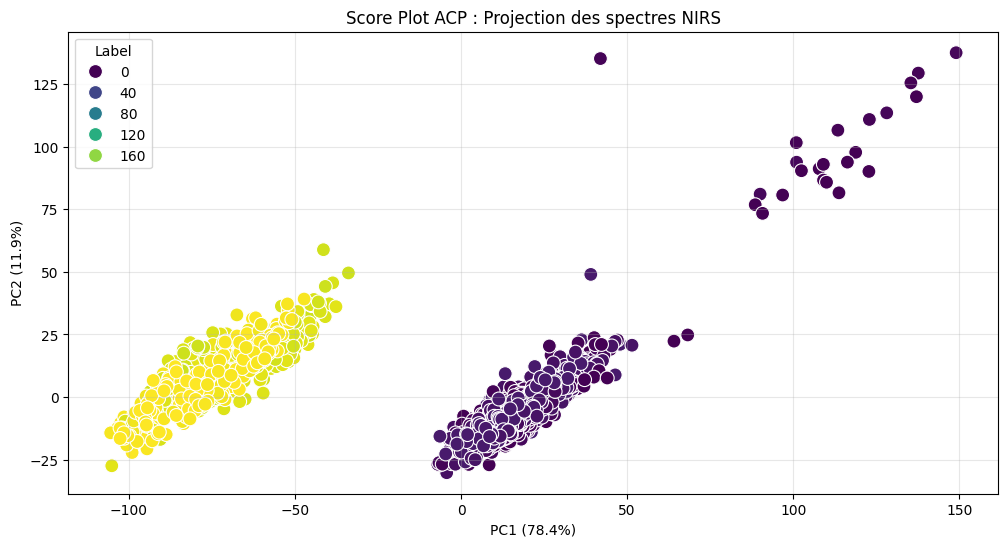

C:\Users\lucas\AppData\Local\Temp\ipykernel_23376\3595198016.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Dates_Delta', data=data, palette='viridis')


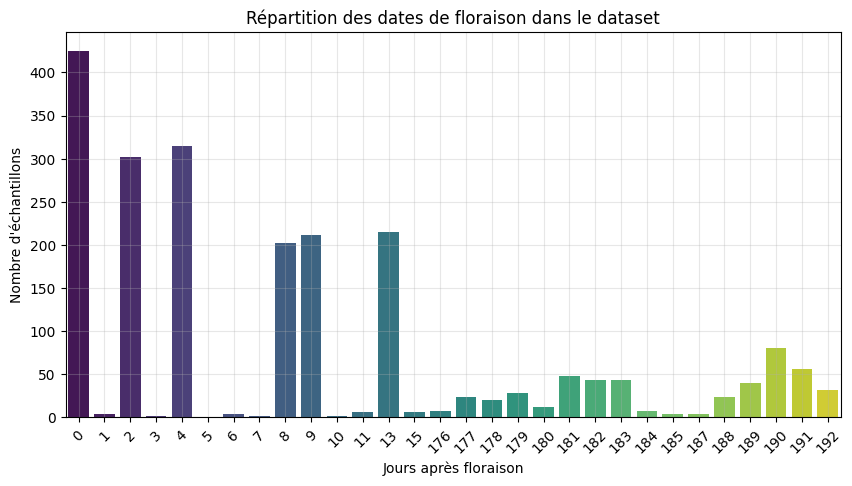

In [5]:
# Vizualisation par dates
df_pca = pd.DataFrame(data=X_pca, columns=["PC1", "PC2"])
df_pca['Label'] = data['Dates_Delta'].values

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Label', palette='viridis', s=100)
var_exp = pca.explained_variance_ratio_
plt.xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")

plt.title("Score Plot ACP : Projection des spectres NIRS")
plt.grid(alpha=0.3)
plt.show()

# Répartition des dates dans le dataset
plt.figure(figsize=(10, 5))
sns.countplot(x='Dates_Delta', data=data, palette='viridis')
plt.title("Répartition des dates de floraison dans le dataset")
plt.xlabel("Jours après floraison")
plt.ylabel("Nombre d'échantillons")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

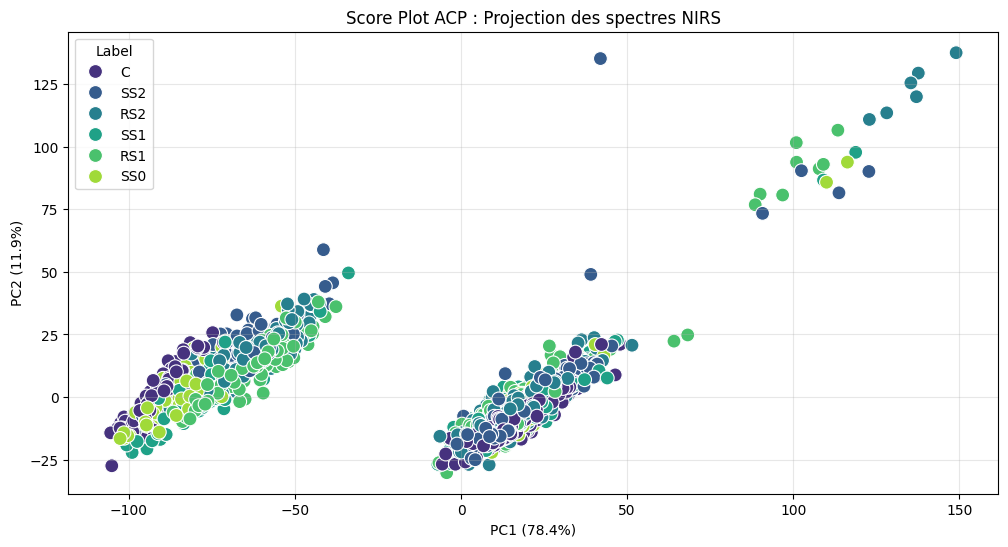

C:\Users\lucas\AppData\Local\Temp\ipykernel_23376\3398081558.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Traitement', data=data, palette='viridis')


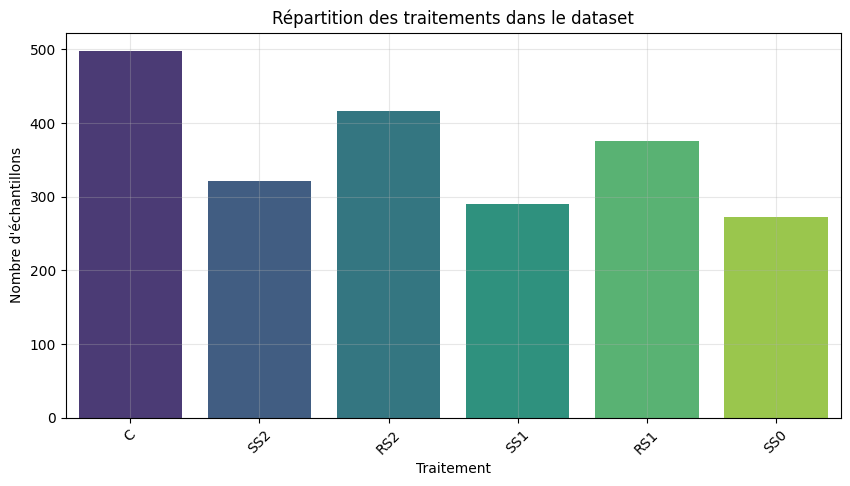

In [6]:
# Vizualisation par experience
df_pca = pd.DataFrame(data=X_pca, columns=["PC1", "PC2"])
df_pca['Label'] = data['Traitement'].values

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Label', palette='viridis', s=100)
var_exp = pca.explained_variance_ratio_
plt.xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")

plt.title("Score Plot ACP : Projection des spectres NIRS")
plt.grid(alpha=0.3)
plt.show()

# Répartition des traitements dans le dataset
plt.figure(figsize=(10, 5))
sns.countplot(x='Traitement', data=data, palette='viridis')
plt.title("Répartition des traitements dans le dataset")
plt.xlabel("Traitement")
plt.ylabel("Nombre d'échantillons")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

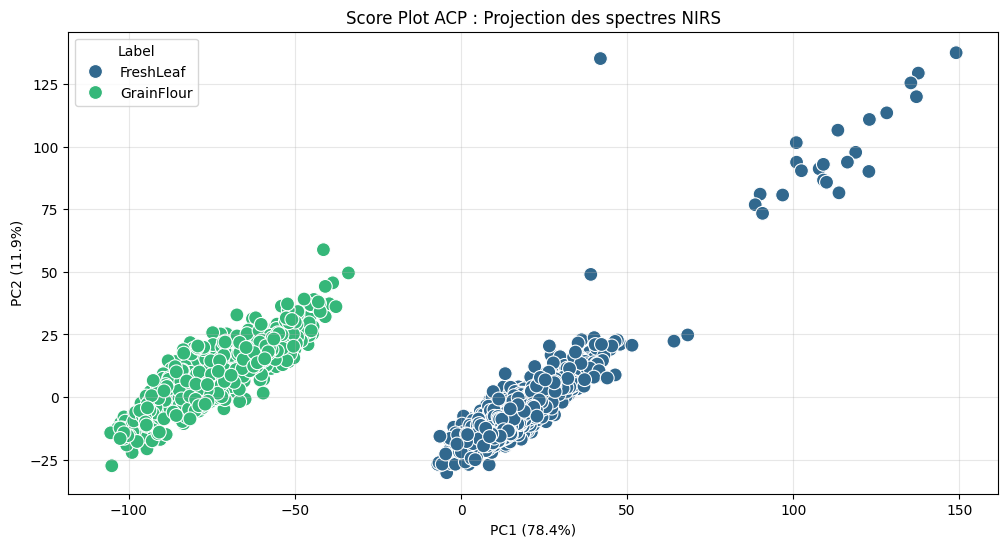

C:\Users\lucas\AppData\Local\Temp\ipykernel_23376\399608902.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sample', data=data, palette='viridis')


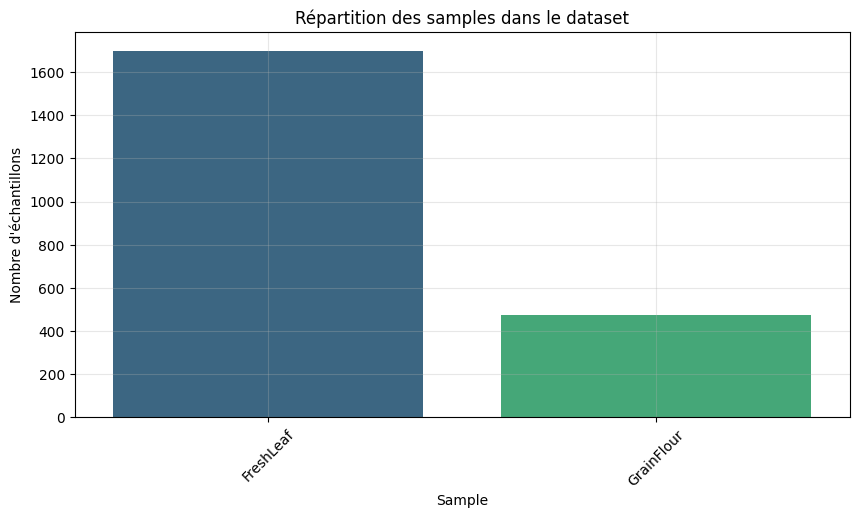

In [7]:
# Vizualisation par sample
df_pca = pd.DataFrame(data=X_pca, columns=["PC1", "PC2"])
df_pca['Label'] = data['Sample'].values

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Label', palette='viridis', s=100)
var_exp = pca.explained_variance_ratio_
plt.xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")

plt.title("Score Plot ACP : Projection des spectres NIRS")
plt.grid(alpha=0.3)
plt.show()

# Répartition des traitements dans le dataset
plt.figure(figsize=(10, 5))
sns.countplot(x='Sample', data=data, palette='viridis')
plt.title("Répartition des samples dans le dataset")
plt.xlabel("Sample")
plt.ylabel("Nombre d'échantillons")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

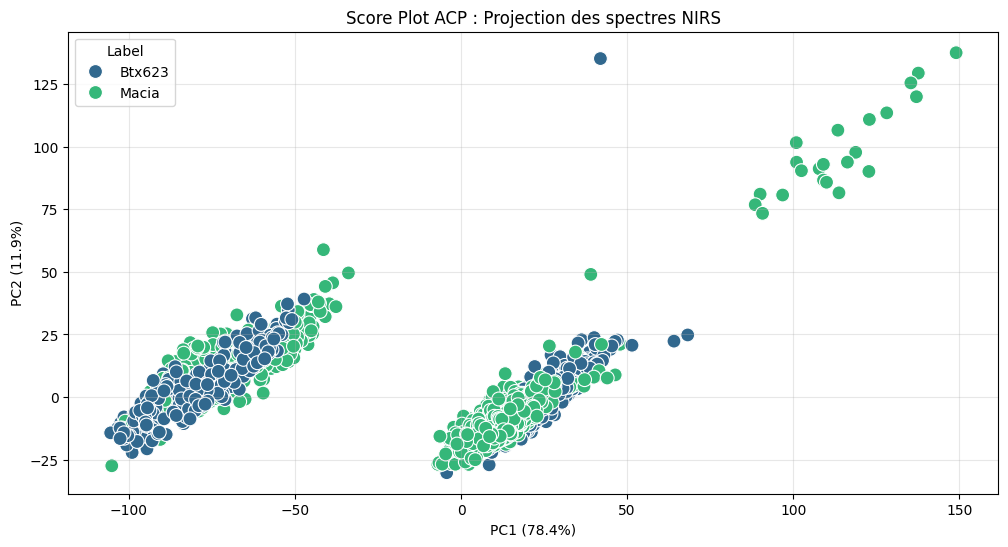

C:\Users\lucas\AppData\Local\Temp\ipykernel_23376\419617782.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Genotype', data=data, palette='viridis')


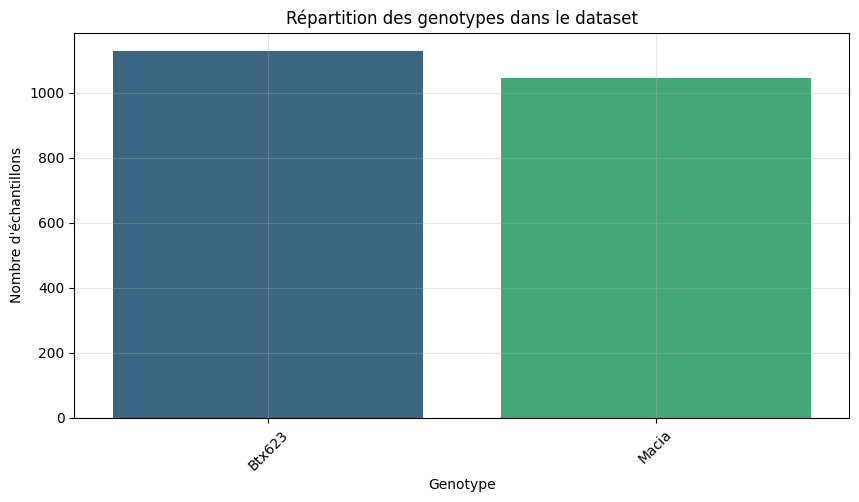

In [8]:
# Vizualisation par genotype
df_pca = pd.DataFrame(data=X_pca, columns=["PC1", "PC2"])
df_pca['Label'] = data['Genotype'].values

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Label', palette='viridis', s=100)
var_exp = pca.explained_variance_ratio_
plt.xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")

plt.title("Score Plot ACP : Projection des spectres NIRS")
plt.grid(alpha=0.3)
plt.show()

# Répartition des traitements dans le dataset
plt.figure(figsize=(10, 5))
sns.countplot(x='Genotype', data=data, palette='viridis')
plt.title("Répartition des genotypes dans le dataset")
plt.xlabel("Genotype")
plt.ylabel("Nombre d'échantillons")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

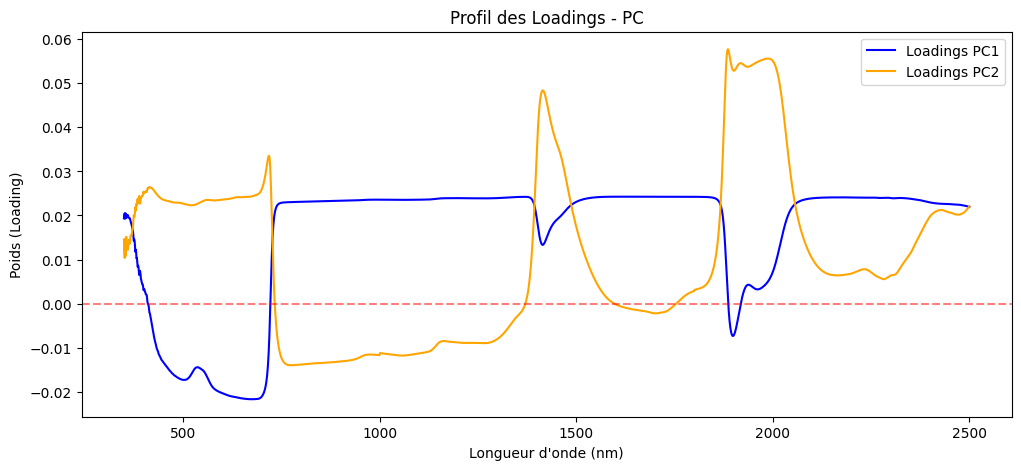

In [ ]:
# Analyse des composantes principales
loadings = pca.components_

plt.figure(figsize=(12, 5))
# On trace le loading de la première composante (index 0)
plt.plot(NIRS_INDEXES_INT, loadings[0, :], label='Loadings PC1', color='blue')
plt.plot(NIRS_INDEXES_INT, loadings[1, :], label='Loadings PC2', color='orange')
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # Ligne de base

plt.xlabel('Longueur d\'onde (nm)')
plt.ylabel('Poids (Loading)')
plt.title('Profil des Loadings - PC')
plt.legend()
plt.show()

Varimax: n_rows=2151, n_cols=2


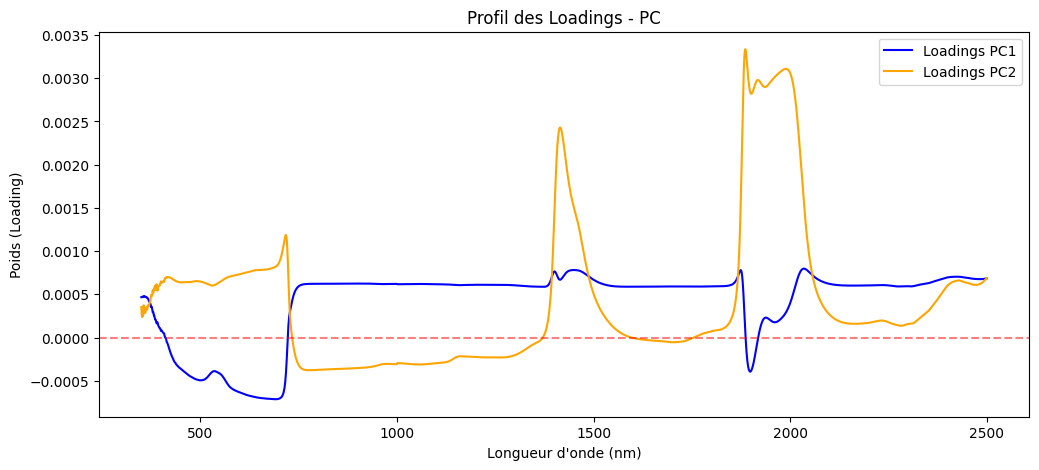

In [14]:
# Varimax
loadings_varimax, R = varimax(loadings.T)
loadings_varimax = loadings_varimax.T

plt.figure(figsize=(12, 5))
# On trace le loading de la première composante (index 0)
plt.plot(NIRS_INDEXES_INT, loadings_varimax[0, :], label='Loadings PC1', color='blue')
plt.plot(NIRS_INDEXES_INT, loadings_varimax[1, :], label='Loadings PC2', color='orange')
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # Ligne de base

plt.xlabel('Longueur d\'onde (nm)')
plt.ylabel('Poids (Loading)')
plt.title('Profil des Loadings - PC')
plt.legend()
plt.show()

In [21]:
# PCA et Varimax sur les dérivées secondes
X_derived = savgol_filter(X, window_length=15, polyorder=2, deriv=2)
pca_derived = PCA(n_components=2)
X_derived_scaled = StandardScaler(with_std=False).fit_transform(X_derived)
X_derived_pca = pca_derived.fit_transform(X_derived_scaled)

loadings_derived = pca_derived.components_
loadings_derived_varimax, R = varimax(loadings_derived.T)
loadings_derived_varimax = loadings_derived_varimax.T

print("Explained variance ratio dérivée 2nd", pca_derived.explained_variance_ratio_)
print("Total explained variance ratio dérivée 2nd:", np.sum(pca_derived.explained_variance_ratio_))

Varimax: n_rows=2151, n_cols=2
Explained variance ratio dérivée 2nd [0.87390572 0.04904841]
Total explained variance ratio dérivée 2nd: 0.9229541367758493


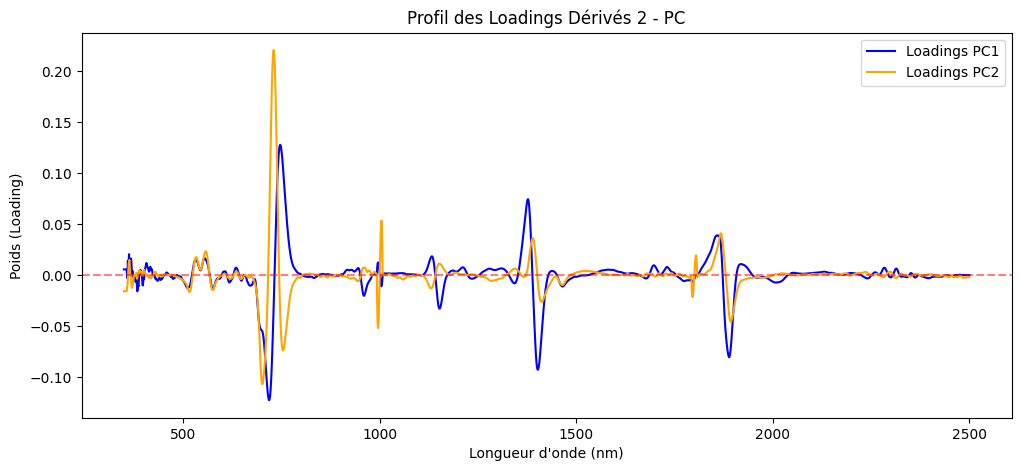

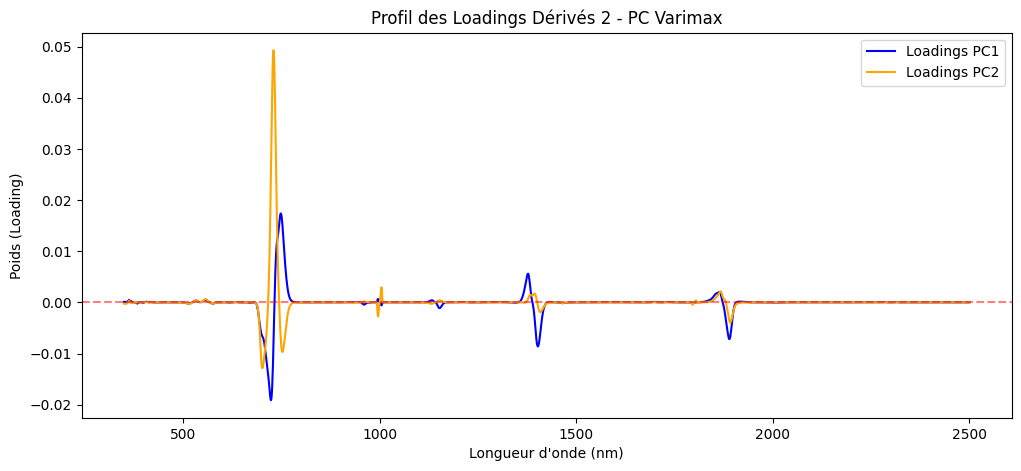

In [20]:
# Plot des loadings pour les dérivées secondes
plt.figure(figsize=(12, 5))
# On trace le loading de la première composante (index 0)
plt.plot(NIRS_INDEXES_INT, loadings_derived[0, :], label='Loadings PC1', color='blue')
plt.plot(NIRS_INDEXES_INT, loadings_derived[1, :], label='Loadings PC2', color='orange')
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # Ligne de base

plt.xlabel('Longueur d\'onde (nm)')
plt.ylabel('Poids (Loading)')
plt.title('Profil des Loadings Dérivés 2 - PC')
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
# On trace le loading de la première composante (index 0)
plt.plot(NIRS_INDEXES_INT, loadings_derived_varimax[0, :], label='Loadings PC1', color='blue')
plt.plot(NIRS_INDEXES_INT, loadings_derived_varimax[1, :], label='Loadings PC2', color='orange')
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # Ligne de base

plt.xlabel('Longueur d\'onde (nm)')
plt.ylabel('Poids (Loading)')
plt.title('Profil des Loadings Dérivés 2 - PC Varimax')
plt.legend()
plt.show()